# Full 6-DOF single stage to orbit with motor thrust-vector control

This notebook integrates one `Flight` continuously from a launch rail through a complete low-Earth orbit. The vehicle is an ordinary `Rocket` running RocketPy's full 13-state, 6-DOF equations. All powered acceleration comes from a `GenericMotor`: there is no custom `Flight` force, fabricated orbital state, impulse, or guidance class.

The motor owns a state-aware `thrust_vector`. A small function commands its body-frame direction so the actual motor force follows a prescribed inertial pitch program. The didactic motor is gimballed through the instantaneous vehicle center of mass, so it generates force without a nozzle lever-arm moment. This ideal center-of-mass, wide-angle actuator is useful for exercising the unified API, but it is not a buildable SSTO propulsion layout.

In [13]:
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np

from rocketpy import (
    Atmosphere,
    Datum,
    Earth,
    Environment,
    Epoch,
    NRLMSISE00AtmosphereLayer,
    Flight,
    GenericMotor,
    Rocket,
    Space,
    enable_logging,
)

## Full Earth kinematics and implicit SPICE

`Datum` supplies precession, nutation, polar motion, Earth rotation, UT1, and leap-second-aware GCRF/ITRF transformations. `Space(["sun", "moon"])` prepares one shared SPICE ephemeris immediately. On first use RocketPy logs and downloads the 31 MiB JPL DE440s kernel into its cache; later runs reuse it. Kernel preparation happens here, not inside the Flight derivative. DE440s is valid from 1849 through 2150.

In [14]:
enable_logging("INFO")

epoch = Epoch.from_datetime(datetime(2026, 1, 1, 18, tzinfo=UTC))
launch_weather = Environment(
    date=epoch.to_datetime(),
    latitude=0.0,
    longitude=-60.7,
    elevation=0.0,
)
earth = Earth(
    datum=Datum(),
    geopotential="egm2008",
    atmosphere=Atmosphere(
        {
            -np.inf: launch_weather,
            80_000.0: NRLMSISE00AtmosphereLayer(),
        },
        transition_width=10_000.0,
    ),
)
space = Space(["sun", "moon"])
print("SPICE bodies:", [body.name for body in space.bodies])

rocketpy - INFO - Using cached SPICE kernel /home/phmb/.cache/rocketpy/de440s.bsp


SPICE bodies: ['sun', 'moon']


## Conceptual vehicle and real thrust curve

The vehicle starts at 205 tonnes and burns down to 25 tonnes. Its high mass ratio and roughly 446 s effective specific impulse are deliberately optimistic. The motor has a 4 MN boost plateau followed by a 1.68 MN sustainer. Its chamber, dry center of mass, and idealized gimbal pivot are centered on the vehicle origin so the commanded vector passes through the center of mass throughout the burn.

In [15]:
BURN_TIME = 400.0
BOOST_END = 50.0
PROPAGATION_TIME = 6_200.0

thrust_curve = np.array(
    [
        [0.0, 4.00e6],
        [BOOST_END, 4.00e6],
        [BOOST_END + 0.1, 1.68e6],
        [BURN_TIME, 1.68e6],
    ]
)
motor = GenericMotor(
    thrust_source=thrust_curve,
    burn_time=BURN_TIME,
    chamber_radius=1.5,
    chamber_height=25.0,
    chamber_position=0.0,
    propellant_initial_mass=180_000.0,
    nozzle_radius=1.2,
    dry_mass=5_000.0,
    center_of_dry_mass_position=0.0,
    dry_inertia=(1.0e6, 1.0e6, 5.0e4),
    nozzle_position=0.0,
)
vehicle = Rocket(
    radius=1.8,
    mass=20_000.0,
    inertia=(1.0e7, 1.0e7, 5.0e5),
    power_off_drag=0.12,
    power_on_drag=0.12,
    center_of_mass_without_motor=0.0,
)
vehicle.add_motor(motor, position=0.0)
vehicle.set_orbital_drag_model(0.12, np.pi * vehicle.radius**2)
vehicle.set_radiation_properties(1.0, np.pi * vehicle.radius**2)

effective_exhaust_velocity = motor.total_impulse / motor.propellant_initial_mass
print(f"Launch mass:                {vehicle.total_mass(0):10.0f} kg")
print(f"Burnout mass:               {vehicle.total_mass(BURN_TIME):10.0f} kg")
print(f"Motor total impulse:        {motor.total_impulse / 1e6:10.1f} MN s")
print(f"Effective specific impulse: {effective_exhaust_velocity / 9.80665:10.1f} s")
print(f"Initial motor thrust vector: {motor.thrust_vector(0)} N")

Launch mass:                    205000 kg
Burnout mass:                    25000 kg
Motor total impulse:             788.1 MN s
Effective specific impulse:      446.5 s
Initial motor thrust vector: [      0.       0. 4000000.] N


In [16]:
#vehicle.all_info()

## State-aware motor TVC

The table is an explicit pitch program, measured above the instantaneous orbital horizon. The callback builds the desired GCRF direction from radial and prograde unit vectors, then rotates it into the current body frame. `Motor.thrust_vector` multiplies that unit direction by the scalar `Motor.thrust`; therefore compatibility code can continue reading the established scalar curve while Flight consumes the vector force.

In [17]:
pitch_time = np.array(
    [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 250, 300, 350, 400],
    dtype=float,
)
pitch_angle = np.deg2rad(
    [88.6, 88.0, 86.4, 83.6, 81.0, 76.5, 70.7, 63.1,
     54.2, 44.7, 27.1, 14.3, 6.1, 1.6, 0.15]
)

def body_to_gcrf_matrix(quaternion):
    q0, q1, q2, q3 = quaternion
    return np.array(
        [
            [1 - 2 * (q2**2 + q3**2), 2 * (q1*q2 - q0*q3), 2 * (q1*q3 + q0*q2)],
            [2 * (q1*q2 + q0*q3), 1 - 2 * (q1**2 + q3**2), 2 * (q2*q3 - q0*q1)],
            [2 * (q1*q3 - q0*q2), 2 * (q2*q3 + q0*q1), 1 - 2 * (q1**2 + q2**2)],
        ]
    )

def tvc_direction(time, state):
    radial = state.position / np.linalg.norm(state.position)
    orbit_normal = np.cross(state.position, state.velocity)
    orbit_normal /= np.linalg.norm(orbit_normal)
    prograde = np.cross(orbit_normal, radial)
    prograde /= np.linalg.norm(prograde)
    pitch = np.interp(time, pitch_time, pitch_angle)
    desired_gcrf = np.sin(pitch) * radial + np.cos(pitch) * prograde
    return body_to_gcrf_matrix(state.quaternion).T @ desired_gcrf

motor.set_thrust_direction(tvc_direction)

## One 6-DOF Flight from rail to orbit

LSODA is allowed a maximum step of `PROPAGATION_TIME // 25` seconds. It automatically takes much smaller steps across rail exit, the thrust transition, atmospheric flight, and cutoff, while avoiding thousands of unnecessarily small steps during the coast.

In [18]:
flight = Flight.from_launch(
    vehicle,
    earth,
    rail_length=30.0,
    inclination=88.6,
    heading=90.0,
    space=space,
    max_time=PROPAGATION_TIME,
    simulation_mode="6DOF",
    max_time_step=PROPAGATION_TIME // 25,
    rtol=1e-7,
    atol=1e-4,
    ode_solver="LSODA",
)

rocketpy - INFO - Preparing NRLMSISE space-weather drivers for 2026-01-01 through 2026-01-01.
rocketpy - INFO - Starting flight simulation of 'Flight'.
rocketpy - INFO - Entering flight phase 'initial_phase' at t=0.000 s.
rocketpy - INFO - Entering flight phase 'free_flight' at t=2.462 s.
rocketpy - INFO - Simulation completed at time: 6200.0000 s


In [19]:
insertion = flight.orbit.at_time(BURN_TIME)
earth_radius = earth.datum.semi_major_axis
perigee_altitude = flight.orbit.periapsis_radius(BURN_TIME) - earth_radius
apogee_altitude = flight.orbit.apoapsis_radius(BURN_TIME) - earth_radius
period = flight.orbit.period(BURN_TIME)
state = flight.state_at_time(BURN_TIME)
radius = np.linalg.norm(state.position)
radial_speed = np.dot(state.position, state.velocity) / radius
transverse_speed = np.linalg.norm(np.cross(state.position, state.velocity)) / radius
quaternion_norm = np.linalg.norm(state.quaternion)

print(f"Rail exit:                  {flight.out_of_rail_time:10.3f} s")
print(f"Cutoff altitude:            {flight.altitude(BURN_TIME) / 1e3:10.2f} km")
print(f"Cutoff radial speed:        {radial_speed / 1e3:10.3f} km/s")
print(f"Cutoff transverse speed:    {transverse_speed / 1e3:10.3f} km/s")
print(f"Insertion eccentricity:     {insertion.eccentricity:10.6f}")
print(f"Insertion perigee:          {perigee_altitude / 1e3:10.2f} km")
print(f"Insertion apogee:           {apogee_altitude / 1e3:10.2f} km")
print(f"Insertion period:           {period / 60:10.2f} min")
print(f"Coast after cutoff:         {(flight.t_final-BURN_TIME)/period:10.2f} orbits")
print(f"Cutoff quaternion norm:     {quaternion_norm:10.8f}")
print("Per-Flight custom forces:  ", flight.forces)
print("Space bodies:              ", [body.name for body in flight.space.bodies])

Rail exit:                       2.462 s
Cutoff altitude:                180.38 km
Cutoff radial speed:             0.037 km/s
Cutoff transverse speed:         7.806 km/s
Insertion eccentricity:       0.005304
Insertion perigee:              161.94 km
Insertion apogee:               231.69 km
Insertion period:                88.43 min
Coast after cutoff:               1.09 orbits
Cutoff quaternion norm:     1.00000000
Per-Flight custom forces:   []
Space bodies:               ['sun', 'moon']


In [20]:
assert flight.simulation_mode == "6DOF"
assert flight.forces == []
assert [body.name for body in flight.space.bodies] == ["sun", "moon"]
assert perigee_altitude > 150_000.0
assert apogee_altitude < 250_000.0
assert flight.t_final - BURN_TIME > period
assert np.isclose(quaternion_norm, 1.0, atol=1e-7)
assert np.linalg.norm(motor.net_thrust_vector(BURN_TIME + 1, state=state)) == 0.0

In [21]:
#flight.plots.animate_orbit_3d(force_external=True)

## Thrust-vector and trajectory diagnostics

The upper-left panel shows the compatible scalar thrust curve. The upper-right evaluates the actual vector at each integrated powered state and plots its angle away from body `+z`. The large late-burn angle exposes the central idealization rather than hiding it.

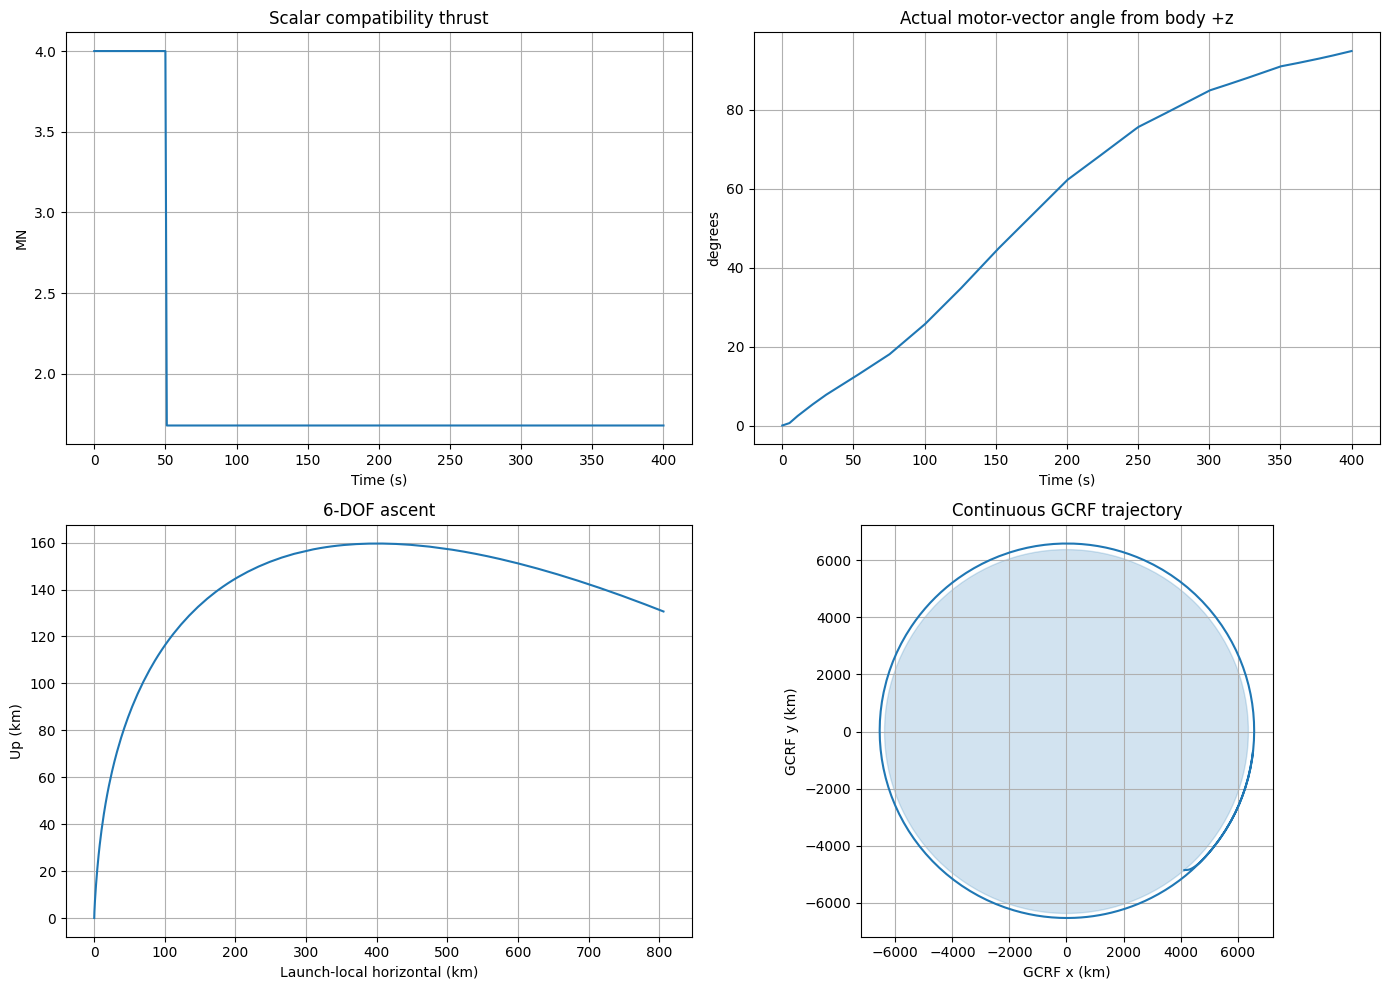

In [22]:
powered_time = flight.time[flight.time <= BURN_TIME]
gimbal_angle = []
for time in powered_time:
    powered_state = flight.state_at_time(time)
    vector = motor.thrust_vector(time, powered_state)
    gimbal_angle.append(np.rad2deg(np.arctan2(np.linalg.norm(vector[:2]), vector[2])))

local_position = flight.position_local()
ascent = flight.time <= BURN_TIME
gcrf_position = flight.position("gcrf")
figure, axes = plt.subplots(2, 2, figsize=(14, 10))

sample_time = np.linspace(0, BURN_TIME, 401)
axes[0, 0].plot(sample_time, [motor.thrust(time) / 1e6 for time in sample_time])
axes[0, 0].set(title="Scalar compatibility thrust", xlabel="Time (s)", ylabel="MN")
axes[0, 1].plot(powered_time, gimbal_angle)
axes[0, 1].set(title="Actual motor-vector angle from body +z", xlabel="Time (s)", ylabel="degrees")
axes[1, 0].plot(
    np.hypot(local_position[ascent, 0], local_position[ascent, 1]) / 1e3,
    local_position[ascent, 2] / 1e3,
)
axes[1, 0].set(title="6-DOF ascent", xlabel="Launch-local horizontal (km)", ylabel="Up (km)")
axes[1, 1].plot(gcrf_position[:, 0] / 1e3, gcrf_position[:, 1] / 1e3)
axes[1, 1].add_patch(plt.Circle((0, 0), earth_radius / 1e3, color="tab:blue", alpha=0.2))
axes[1, 1].set(title="Continuous GCRF trajectory", xlabel="GCRF x (km)", ylabel="GCRF y (km)", aspect="equal")
for axis in axes.flat:
    axis.grid(True)
figure.tight_layout()

In [23]:
# These views remain available individually. The final all_info() call now
# selects them automatically when geodetic height reaches 80 km.
# flight.plots.earth_centered_state()
# flight.plots.geodetic_coordinates()
# flight.plots.orbit_3d(backend="plotly")
# flight.plots.ground_track()
# flight.plots.orbital_elements()
# flight.plots.orbital_acceleration_components()


Low_altitude / Launch-Site Summary (limited to first 80 km geodetic height)


Initial Conditions

Initial time: 0.000 s
Launch-local position - East: 0.00 m | North: -0.00 m | Up: 0.00 m
Earth-fixed velocity - East: -0.00 m/s | North: -0.00 m/s | Up: 0.00 m/s
Launch-local attitude (quaternions) - e0: 0.707 | e1: -0.009 | e2: 0.009 | e3: -0.707
Launch-local Euler Angles - Spin φ: 0.00° | Nutation θ: -1.40° | Precession ψ: -90.00°
Angular Velocity - ω1: -0.00 rad/s | ω2: -0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 0.000 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 30.0 m
Launch Rail Inclination: 88.60°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 2.462 s
Rail Departure Velocity: 24.234 m/s
Rail Departure Stability Margin: 0.000 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 2.012
Rail Departure Reynolds Number: 5.959e+06


80 k

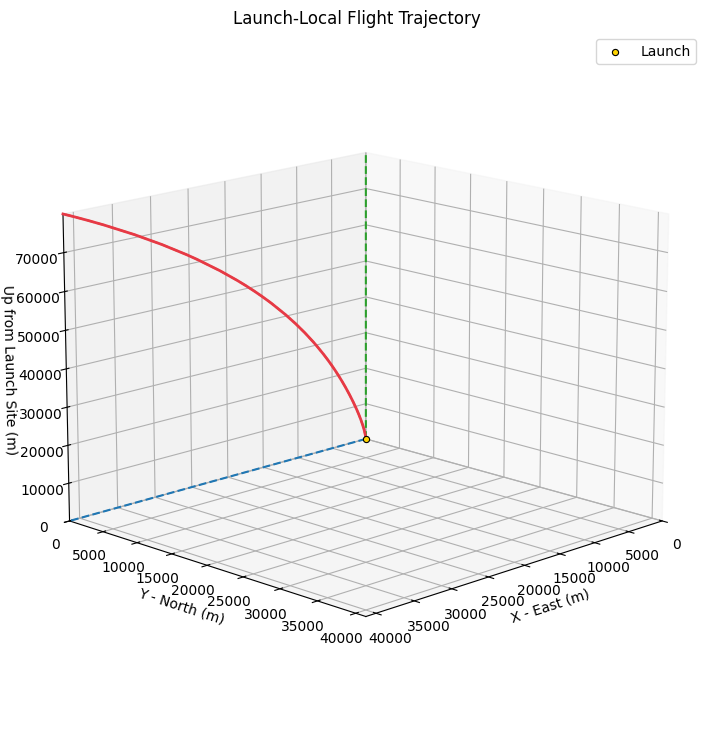



Altitude Data



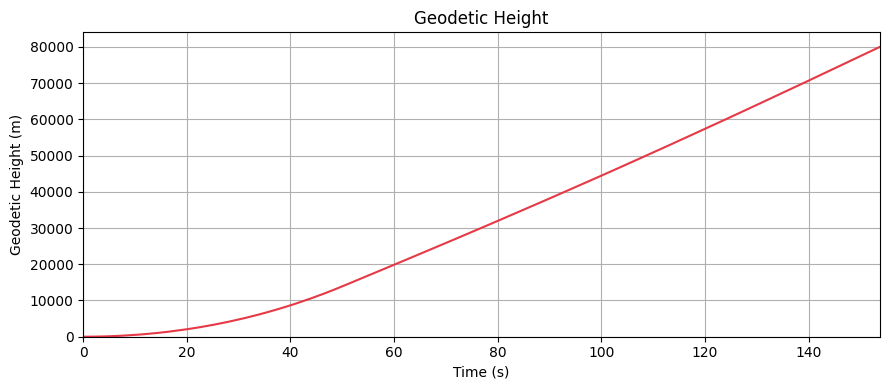



Launch-Local Ground Track



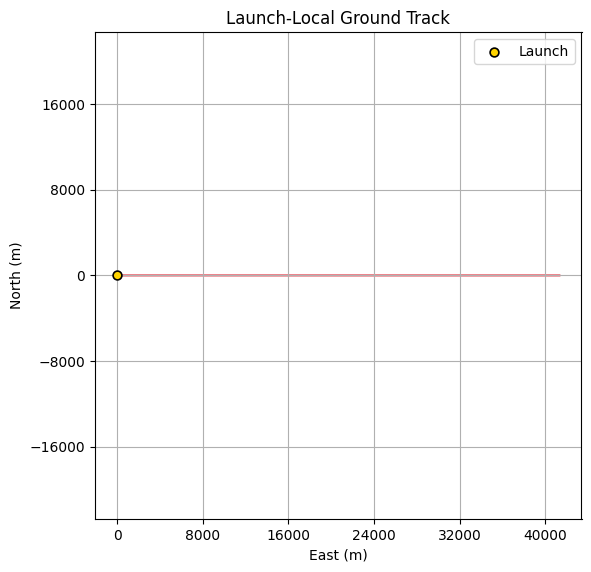



Drift and Bearing Data



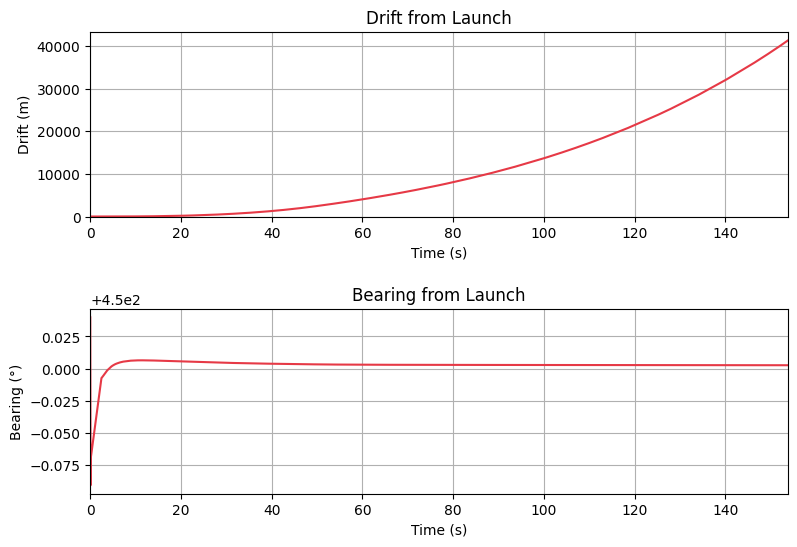



Trajectory Kinematic Plots



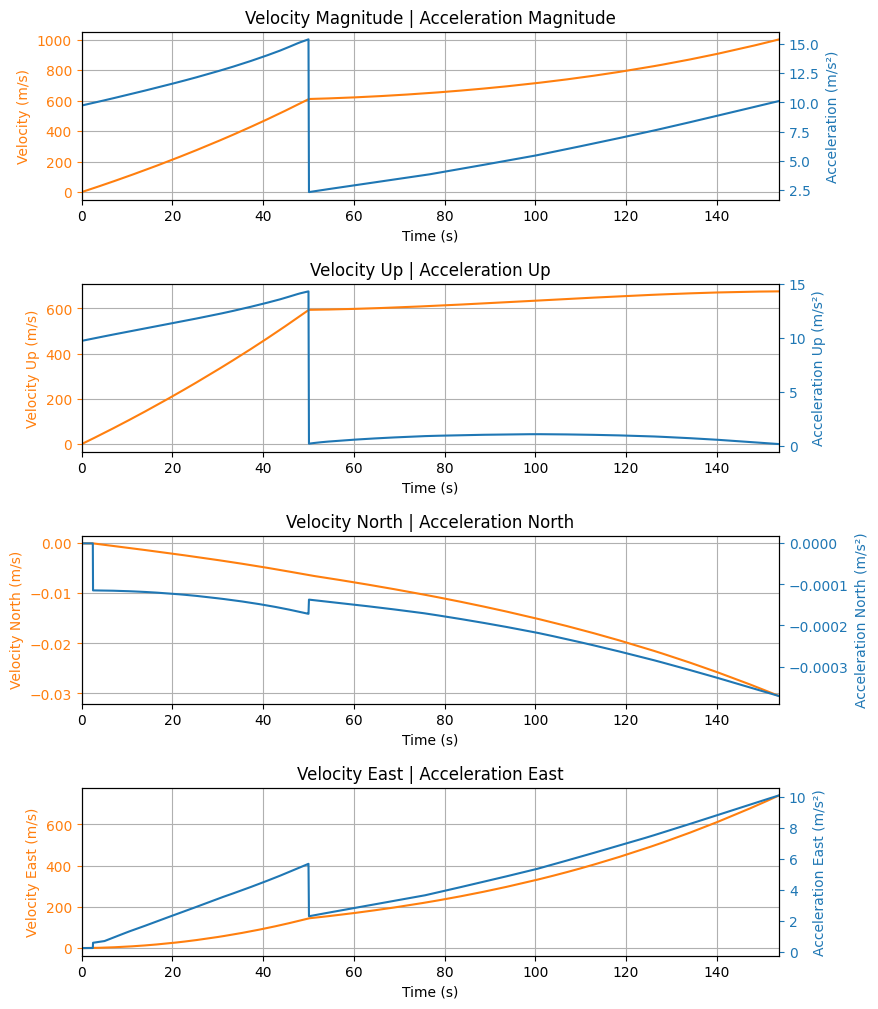



Trajectory Angular Velocity and Acceleration Plots



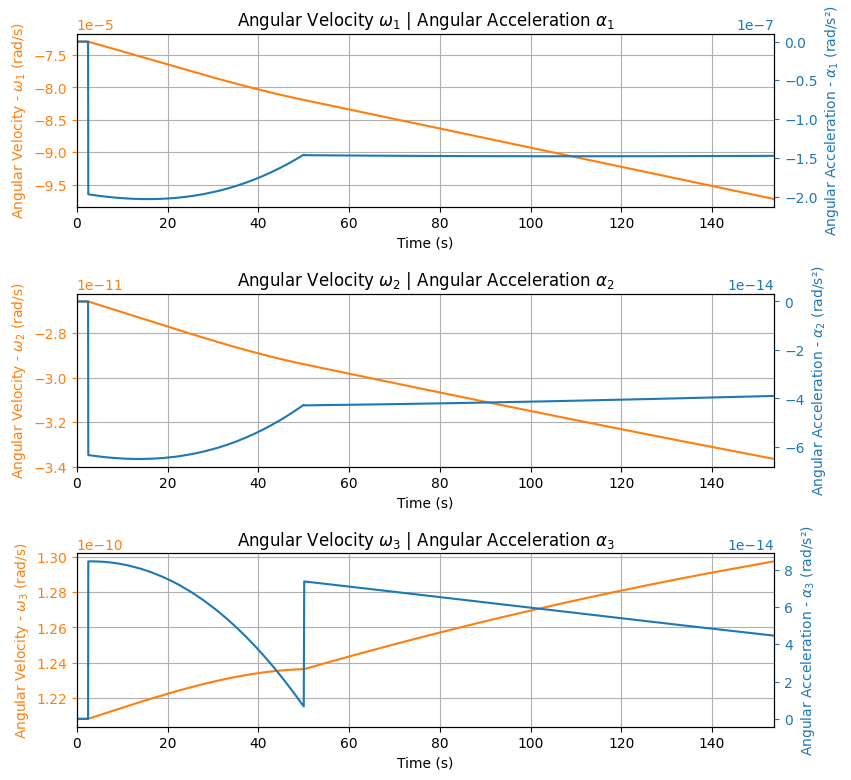



Angle of Attack Plots



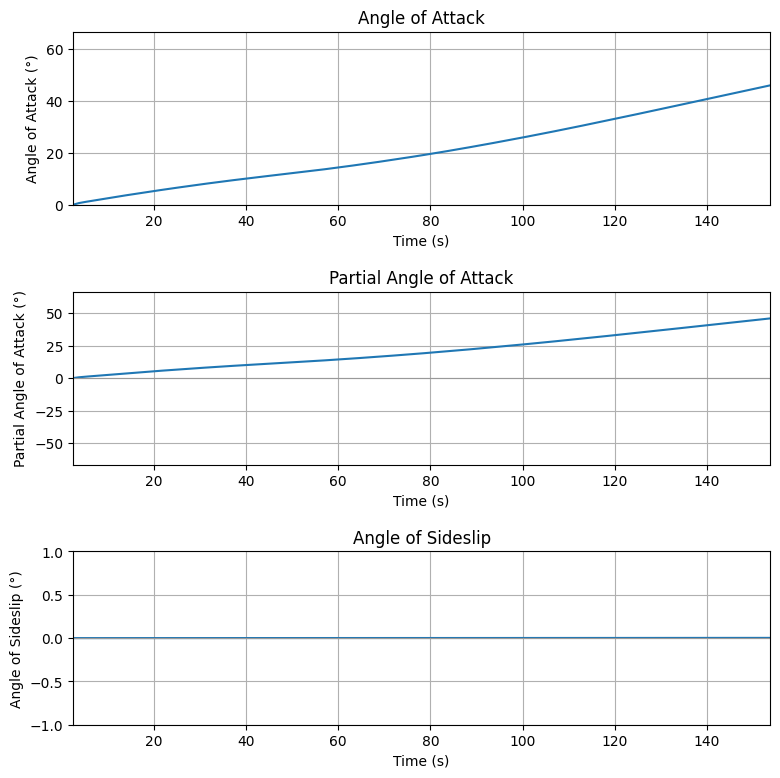



Angular Position Plots



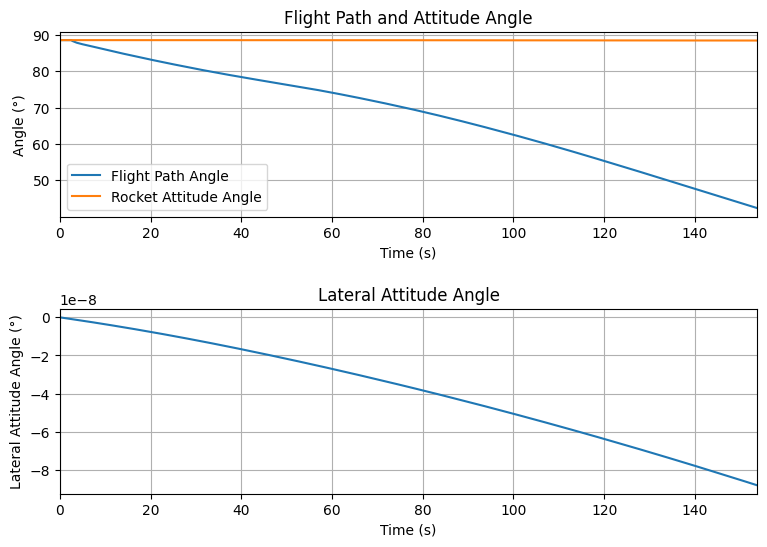



Path, Attitude and Lateral Attitude Angle Plots



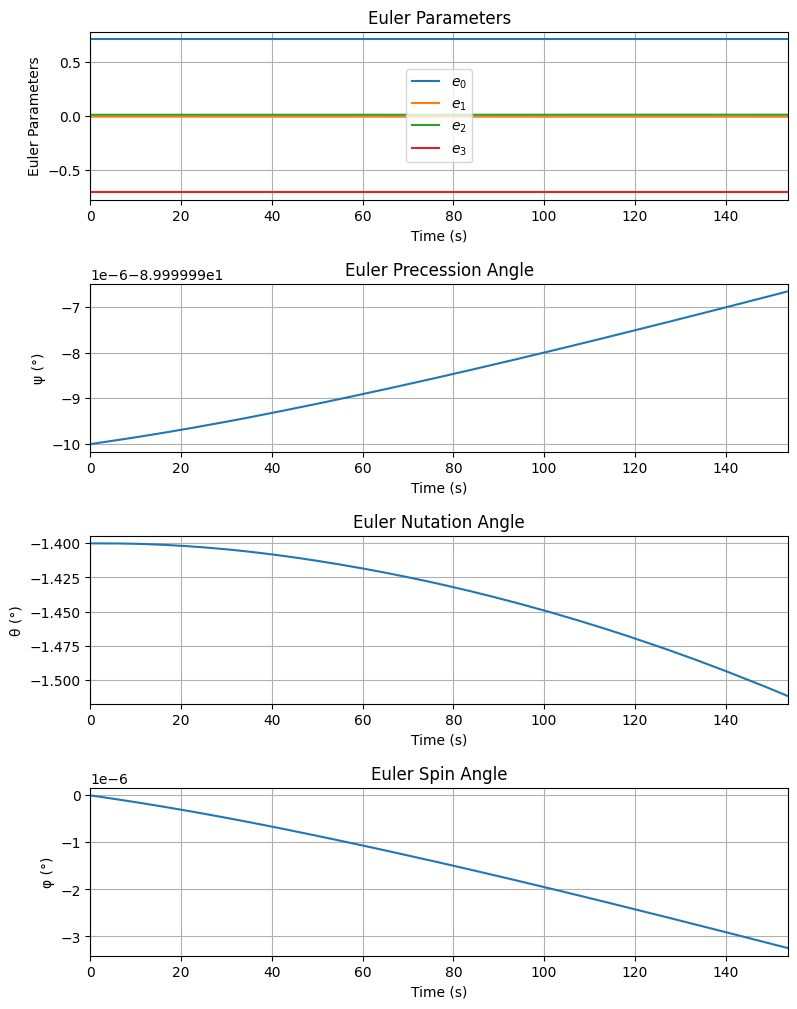



Aerodynamic Forces Plots



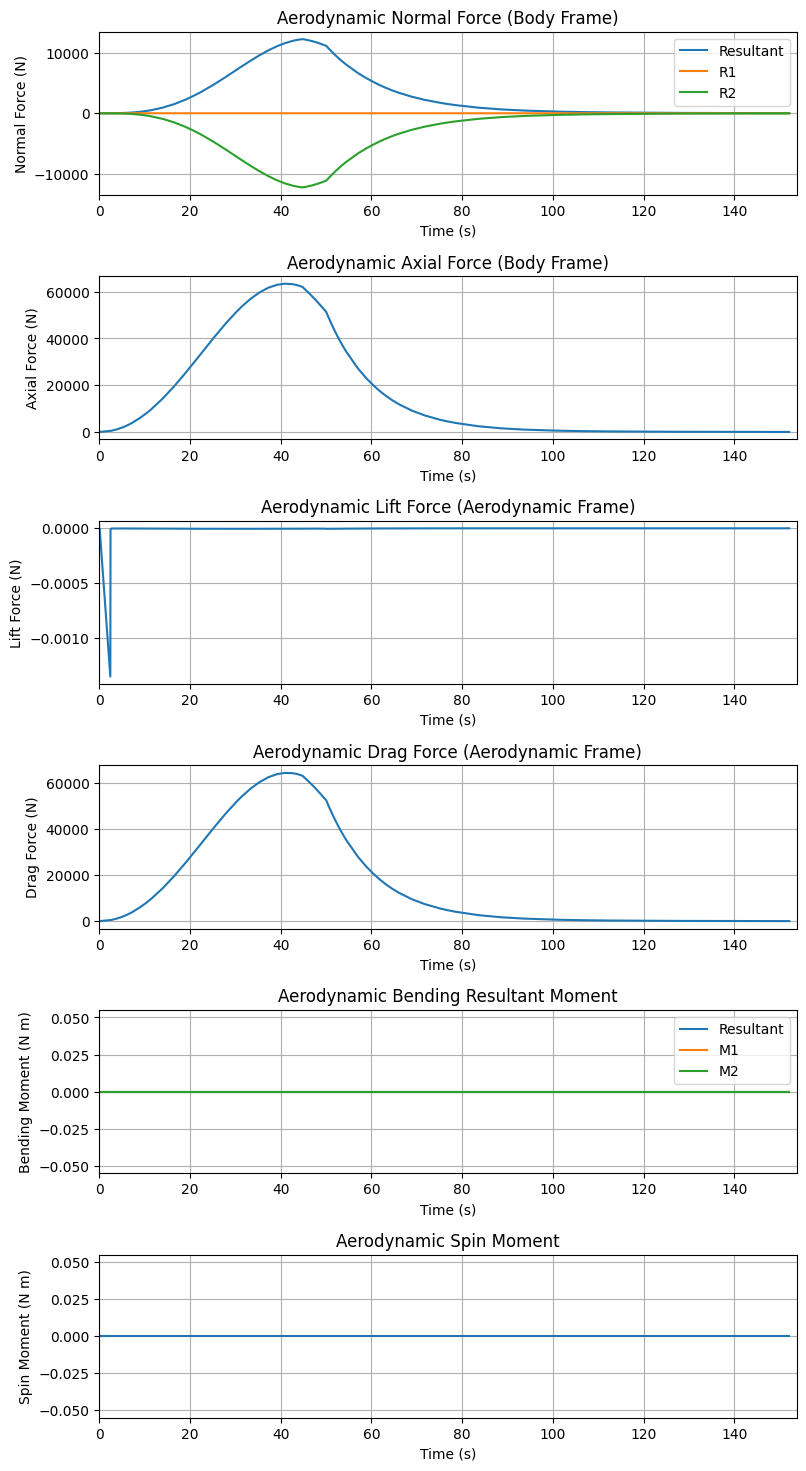



Rail Buttons Bending Moments Plots

No rail buttons were defined. Skipping rail button bending moment plots.


Rail Buttons Forces Plots

No rail buttons were defined. Skipping rail button plots.


Trajectory Energy Plots



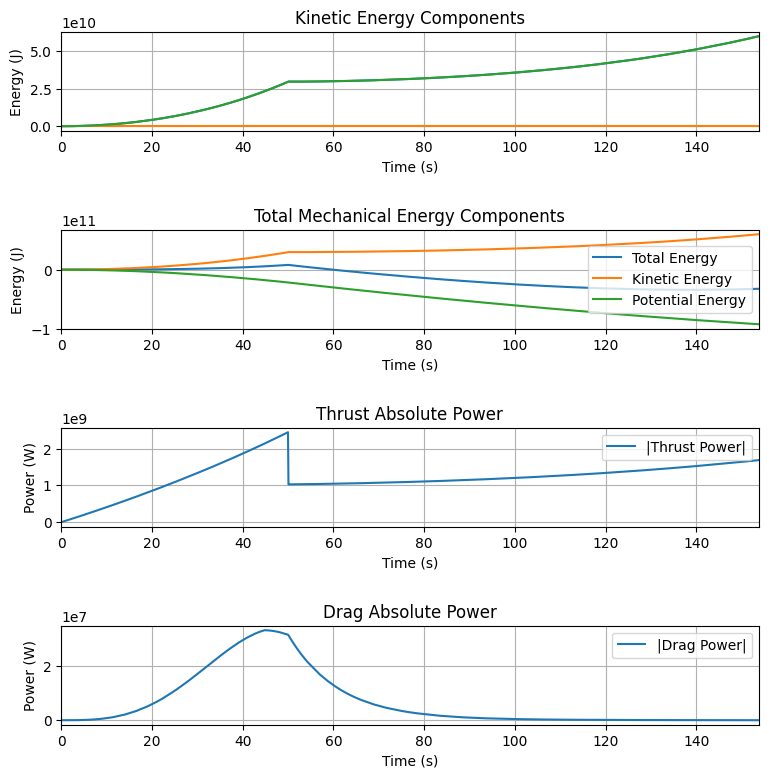



Trajectory Fluid Mechanics Plots



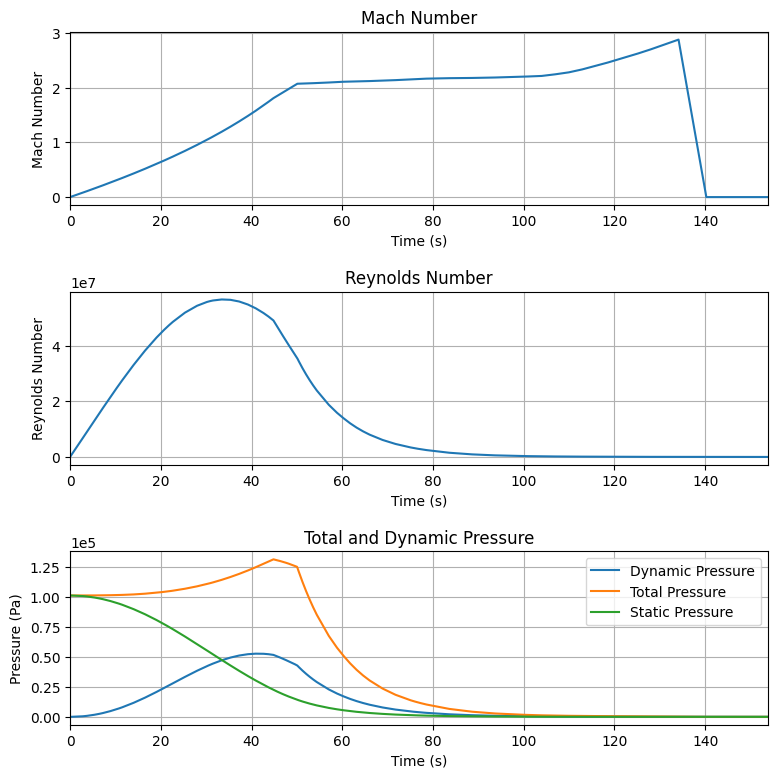



Trajectory Stability and Control Plots



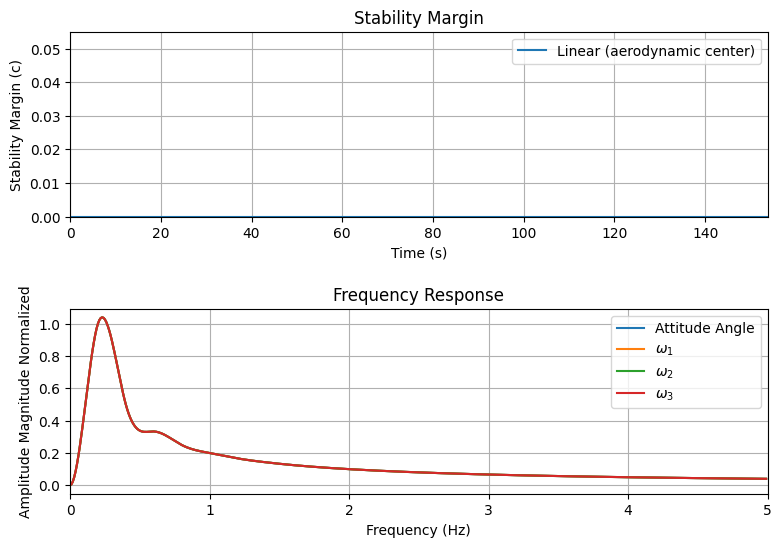

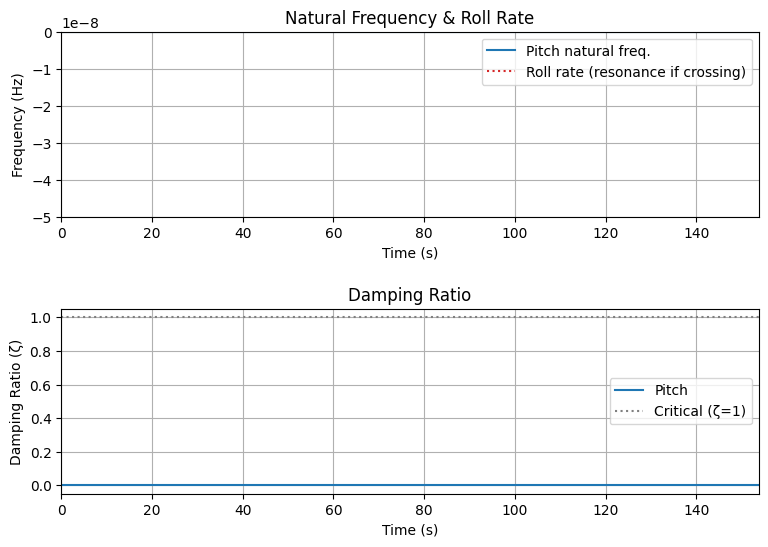



Full Earth-Centered Flight / Orbit View



GCRF State History



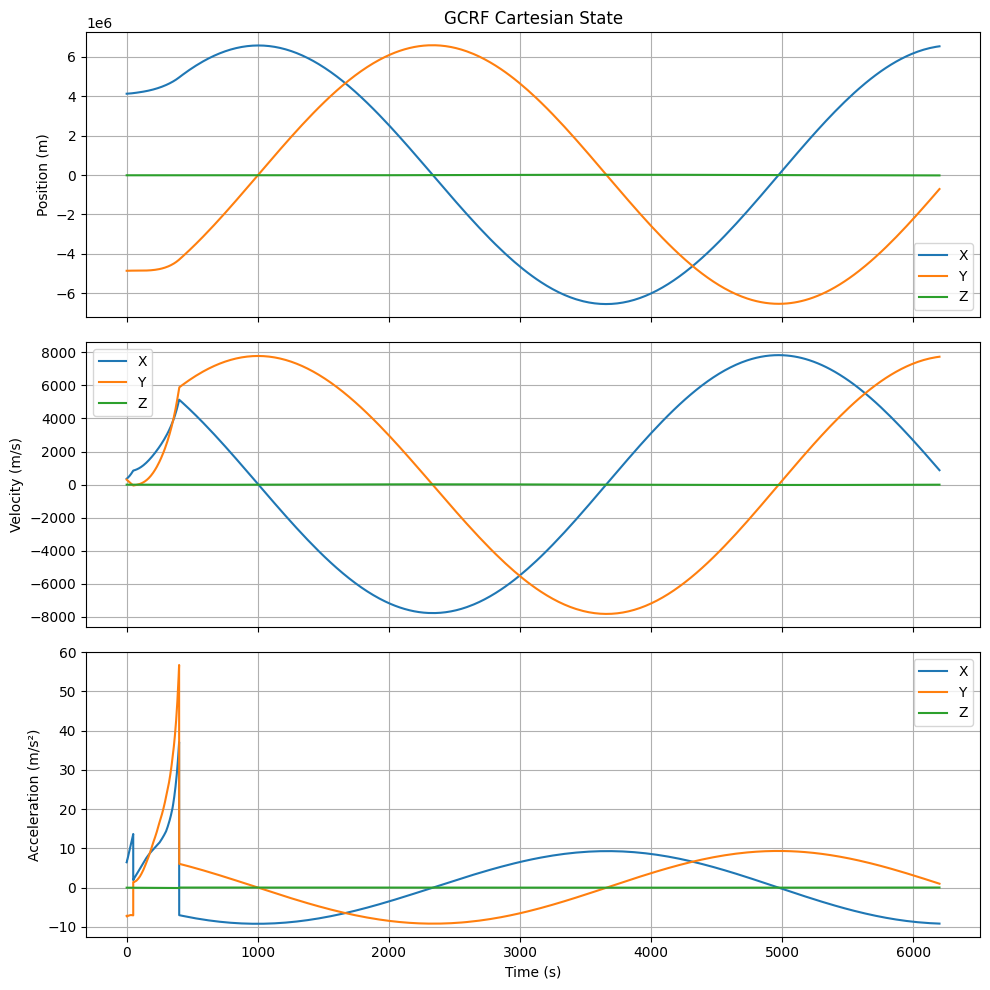



Geodetic Coordinate History



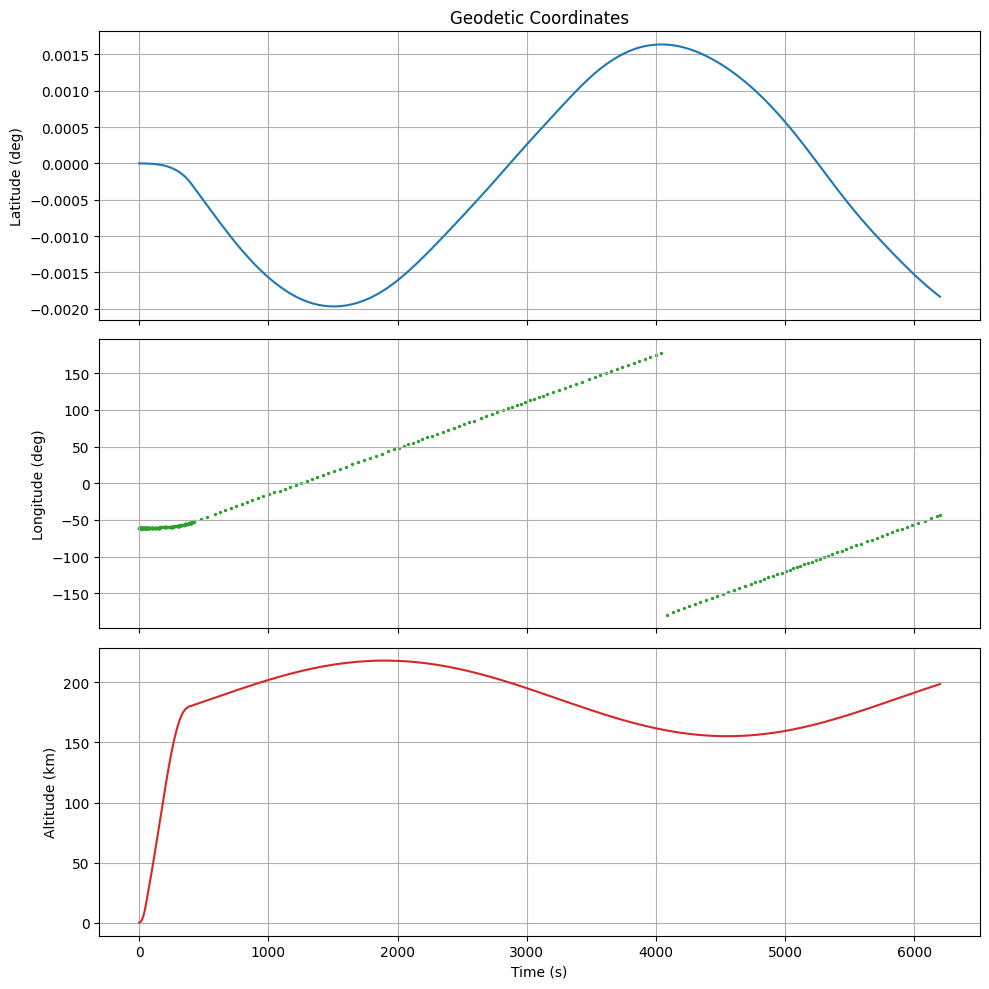



Orbit 3D Plot



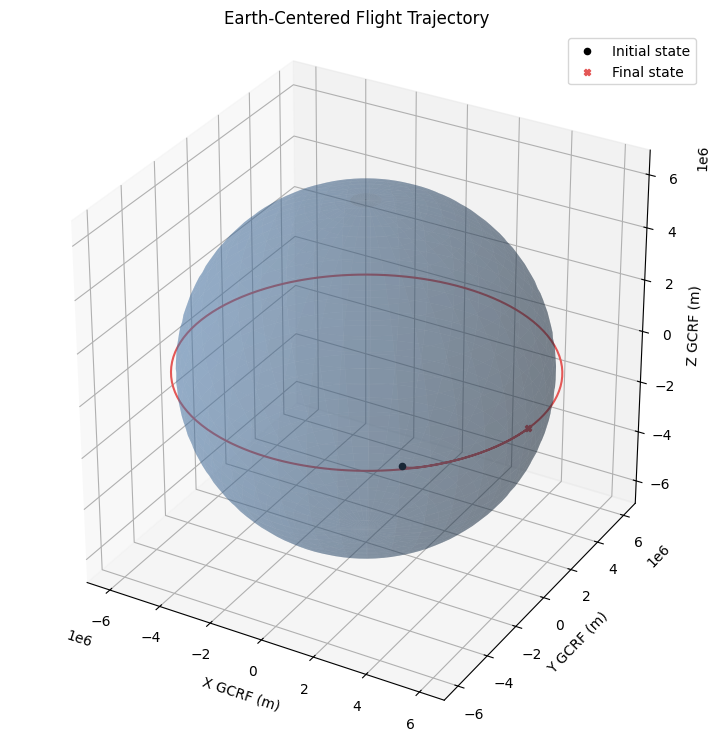



Full Ground Track Plot



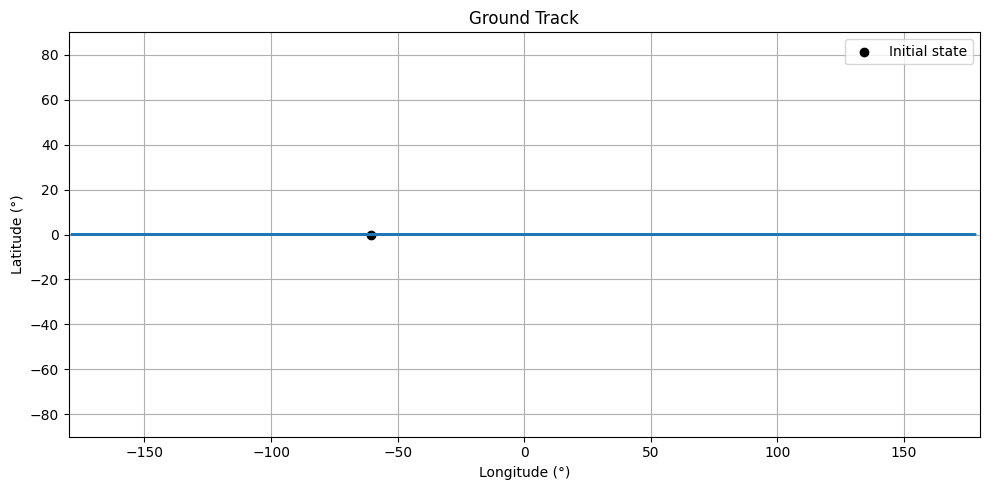



Osculating Orbital Elements



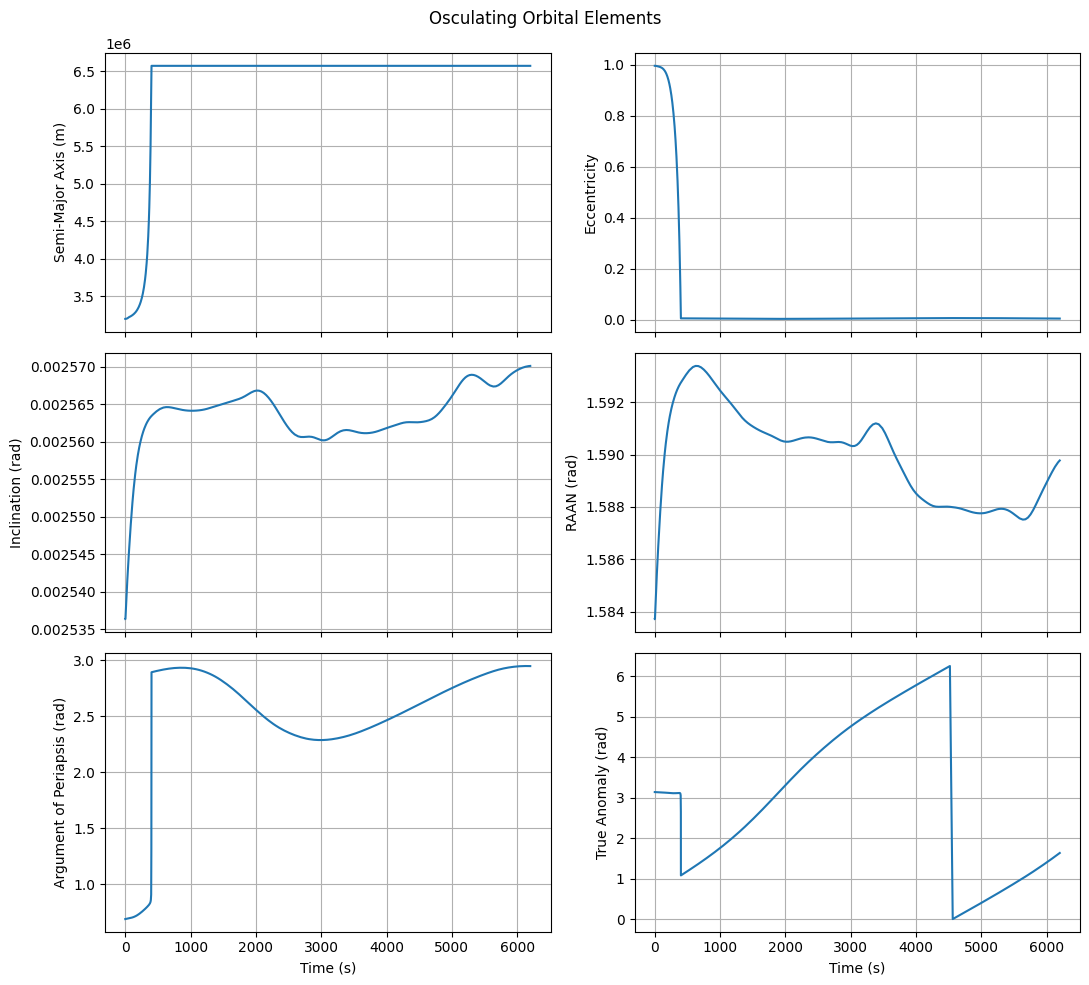



Orbital Acceleration Contributions



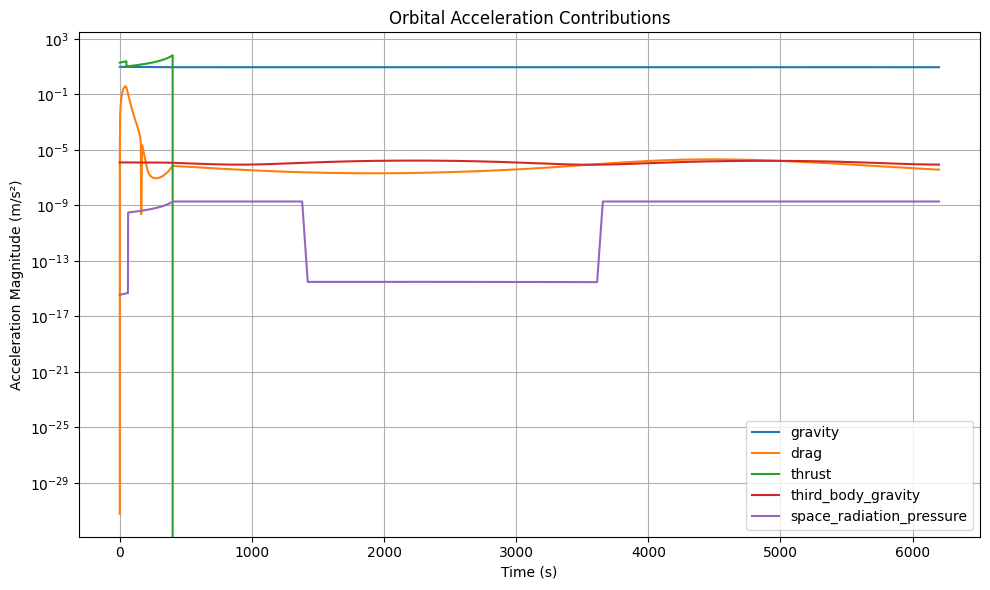



Orbital Accelerations in RTN



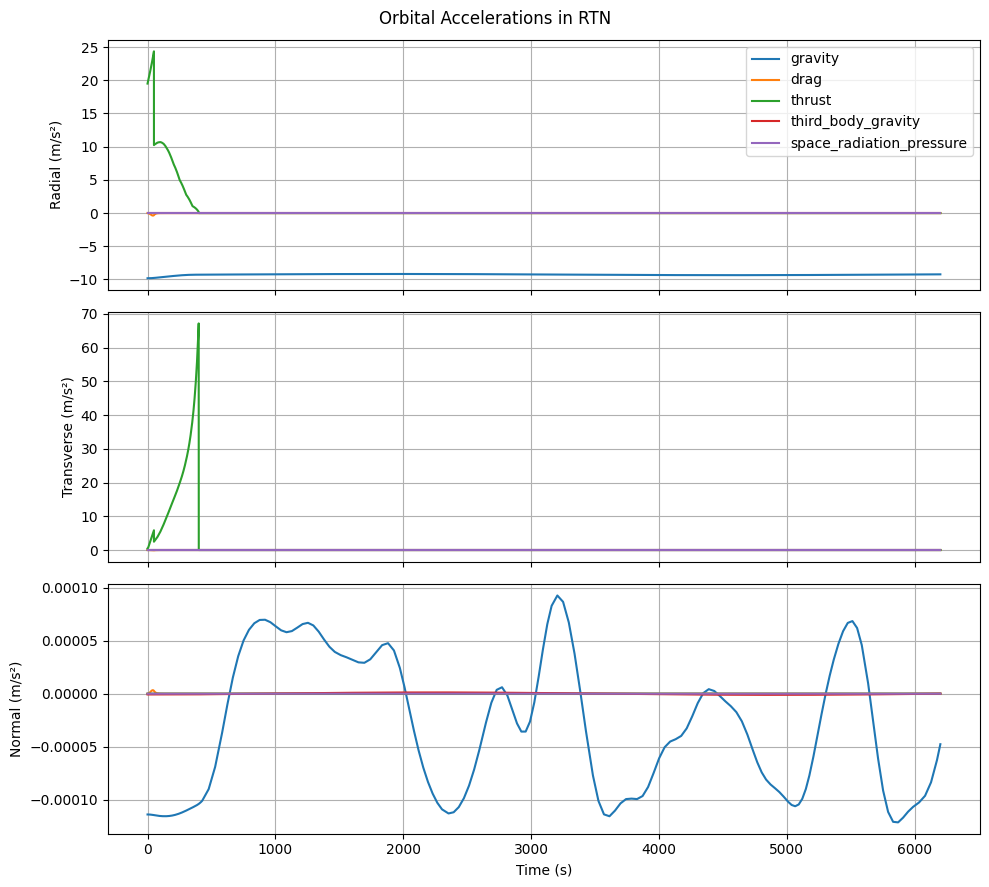



Orbital Invariants



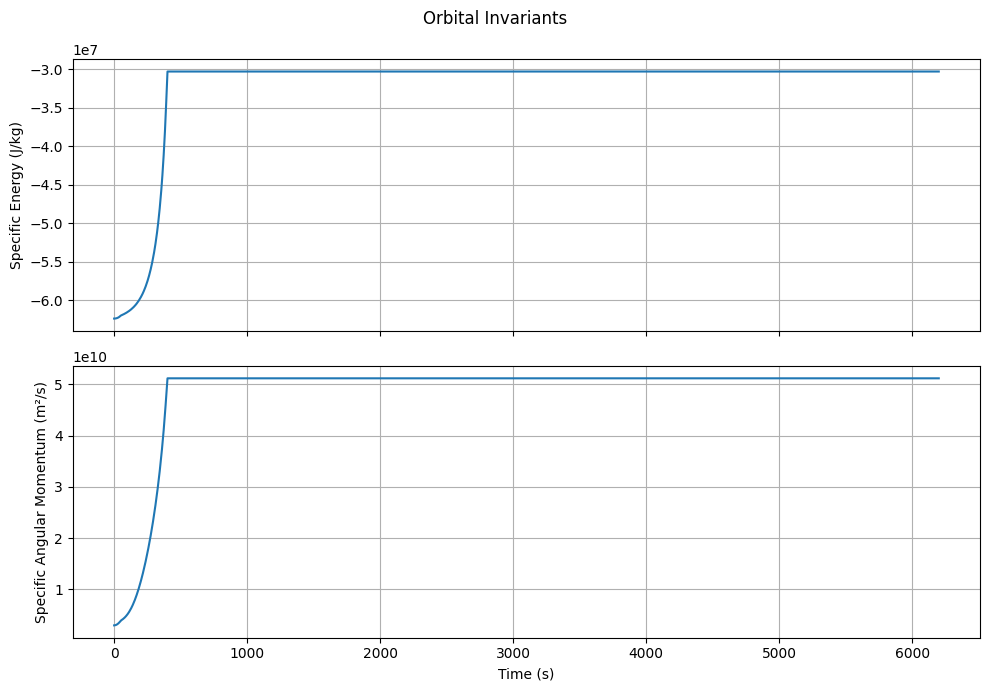

In [24]:
flight.all_info()